Necessary Imports

In [2]:
import pandas as pd
import numpy as np

In [2]:
df1 = pd.read_csv("/Users/apple/Downloads/drive-download-20260310T200602Z-1-001/assignment_investment_rules.csv")
df2 = pd.read_csv("/Users/apple/Downloads/drive-download-20260310T200602Z-1-001/assignment_sector_data.csv")
df3 = pd.read_csv("/Users/apple/Downloads/drive-download-20260310T200602Z-1-001/assignment_mcap.csv")


In [3]:
df2['[Sector'] = df2['[Sector'].fillna('Unknown')

Trying the code for 1 cell in df1


In [29]:
raw_text = df1.iloc[14, 6]
        
        # 4. Handle Empty or Missing Cells safely
        # Sometimes pandas reads empty CSV cells as floats (NaN)
if pd.isna(raw_text):
            portfolio_list = [] # Treat it as an empty portfolio
            
else:
            # 5. Convert the raw text string into a real Python list
            # Converts "['ACC', 'Apollo Tyres']" -> ['ACC', 'Apollo Tyres']
            try:
                portfolio_list = ast.literal_eval(raw_text)
            except (ValueError, SyntaxError):
                # Fallback just in case the text is corrupted
                portfolio_list = []
print(df.columns[6])       

if len(portfolio_list) > 0:
            
            portfolio_df = pd.DataFrame(portfolio_list, columns=['CO_NAME'])
            

2002


In [25]:
portfolio_df['CO_NAME'] = portfolio_df['CO_NAME'].str.strip()
df2['CO_NAME'] = df2['CO_NAME'].str.strip()

In [27]:
matched_df = pd.merge(
    portfolio_df,                                  
    df2[['CO_NAME', '[Sector', '[Industry']],   
    on='CO_NAME',                                  
    how='left'                                      
)

In [28]:
matched_df.head()

,CO_NAME,[Sector,[Industry
0,Ashok Leyland,Automobile,Automobiles - LCVs/HCVs
1,Britannia Inds.,FMCG,Food And Dairy Products - Multinational
2,EPL Ltd,Packaging,Packaging - Others
3,GlaxoSmith C H L,FMCG,Food And Dairy Products - Multinational
4,P & G Hygiene,FMCG,Personal Care - Multinational


In [32]:
year = 2002 

# 1. Slice the MCap data to ONLY get the company names and the year 2002
mcap_for_year = df3[['CO_NAME', str(year)]]
# 2. Perform the Left Merge
# This attaches the 2002 MCap value to your existing portfolio
final_portfolio_df = pd.merge(
    matched_df,         # Your dataframe with the sectors
    mcap_for_year,      # The sliced MCap data for 2002
    on='CO_NAME', 
    how='left'          # Keep all stocks in the portfolio!
)

# 3. Rename the column from '2002' to a generic name like 'MCap'
# This makes your filtering code identical no matter what year you are looping through!
final_portfolio_df.rename(columns={year: 'MCap'}, inplace=True)

In [38]:
final_portfolio_df['2002'].describe

<bound method NDFrame.describe of 0       952.63
1      1453.12
2       738.04
3      1792.51
4       962.98
5      2247.98
6     39553.69
7      8400.75
8       533.61
9     11568.07
10      716.19
11     9289.35
12     5328.08
13      740.65
14      504.96
15     3131.55
16     6616.42
17      765.32
18     6443.87
19     1620.20
Name: 2002, dtype: float64>

In [37]:
# 1. Drop any companies in the master file that have missing MCap for 2002
# (Because the assignment says: "Only stocks with available MCap data... may be ranked")
valid_universe_2002 = mcap_for_year.dropna(subset=['2002'])

# 2. Find the MCap value that represents the 20th percentile (the bottom 20% cutoff)
cutoff_value = valid_universe_2002['2002'].quantile(0.20)

print(f"Any stock with an MCap below {cutoff_value} must be dropped!")

# 3. Now, apply this rule to your portfolio
# Keep only the stocks that have an MCap >= the cutoff value
final_portfolio_df = final_portfolio_df[final_portfolio_df['2002'] >= cutoff_value]

Any stock with an MCap below 2.0 must be dropped!


In [43]:
final_portfolio_df.head(
    
)

,CO_NAME,[Sector,[Industry,2002
0,Wipro,IT - Software,Computers - Software - Large,39553.69
1,St Bk of India,Banks,Banks - Public Sector,11568.07
2,M T N L,Telecomm-Service,Telecommunications - Service Provider,9289.35
3,Dr Reddy's Labs,Pharmaceuticals,Pharmaceuticals - Indian - Bulk Drugs & Formln...,8400.75
4,HDFC Bank,Banks,Banks - Private Sector,6616.42


In [42]:
# Sort the portfolio from Highest MCap to Lowest MCap
final_portfolio_df = final_portfolio_df.sort_values(by='2002', ascending=False)

# Reset the index so your row numbers stay clean (0, 1, 2...)
final_portfolio_df = final_portfolio_df.reset_index(drop=True)

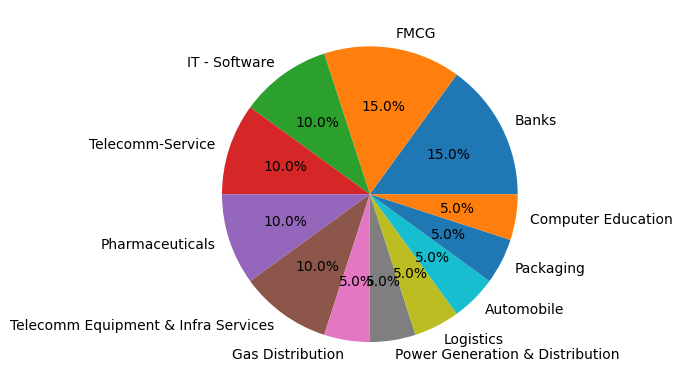

In [47]:
import matplotlib.pyplot as plt

final_portfolio_df['[Sector'].value_counts().plot.pie(autopct='%1.1f%%')

plt.show()

In [50]:
# 1. Sort the portfolio by MCap (Highest to Lowest)
# This is crucial so that the "lowest MCap" stocks are always at the bottom!
final_portfolio_df = final_portfolio_df.sort_values(by='2002', ascending=False).reset_index(drop=True)

# 2. The Dynamic Risk Manager Loop
while True:
    portfolio_size = len(final_portfolio_df)
    
    # Safety catch: If the portfolio is somehow emptied, stop the loop
    if portfolio_size == 0:
        break
        
    # Calculate the max allowed stocks per sector (25% rounded down)
    max_allowed_per_sector = int(portfolio_size * 0.25)
    
    # Count the number of stocks in each sector
    # Note: 'Unknown' is counted automatically as its own bucket here!
    sector_counts = final_portfolio_df['[Sector'].value_counts()
    
    # Find any sectors that have more stocks than the max allowed
    violating_sectors = sector_counts[sector_counts > max_allowed_per_sector]
    
    # If the list of violating sectors is empty, our portfolio is perfectly balanced!
    if violating_sectors.empty:
        break 
        
    # Pick the first sector that is breaking the rule
    sector_to_reduce = violating_sectors.index[0]
    
    # Isolate all stocks currently in that violating sector
    sector_stocks = final_portfolio_df[final_portfolio_df['[Sector'] == sector_to_reduce]
    
    # Since our main dataframe is sorted Highest -> Lowest MCap,
    # the very last item in this sector's subset has the lowest MCap.
    lowest_mcap_index = sector_stocks.index[-1] 
    
    # Drop that specific stock and reset the index
    final_portfolio_df = final_portfolio_df.drop(lowest_mcap_index).reset_index(drop=True)

# --- RESULT ---
print(f"Constraint satisfied! Final portfolio has {len(final_portfolio_df)} stocks.")
print(final_portfolio_df['[Sector'].value_counts(normalize=True) * 100) # View the final percentages

Constraint satisfied! Final portfolio has 20 stocks.
[Sector
Banks                                  15.0
FMCG                                   15.0
IT - Software                          10.0
Telecomm-Service                       10.0
Pharmaceuticals                        10.0
Telecomm Equipment & Infra Services    10.0
Gas Distribution                        5.0
Power Generation & Distribution         5.0
Logistics                               5.0
Automobile                              5.0
Packaging                               5.0
Computer Education                      5.0
Name: proportion, dtype: float64


THE MAIN CODE FOR THE WHOLE DATAFRAME (DF1)

EXCLUSION LOG

In [5]:
import ast
import pandas as pd


year_columns = df1.columns[1:].tolist()

# Build MCap lookup dict per year for fast access
mcap_lookup = {}
for year in year_columns:
    if year in df3.columns:
        mcap_lookup[year] = df3.set_index("CO_NAME")[year].to_dict()

missing_log = []

for index, row in df1.iterrows():
    strategy_name = row["strat_name"]

    for year in year_columns:
        raw_text = row[year]

        if pd.isna(raw_text):
            portfolio_list = []
        else:
            try:
                portfolio_list = ast.literal_eval(raw_text)
            except (ValueError, SyntaxError):
                portfolio_list = []

        if len(portfolio_list) > 0:
            year_mcap = mcap_lookup.get(year, {})

            for stock in portfolio_list:
                val = year_mcap.get(stock)
                if val is None or pd.isna(val):
                    missing_log.append({
                        "strat_name": strategy_name,
                        "year"      : year,
                        "stock"     : stock,
                        "reason"    : "Missing MCap - excluded from ranking"
                    })

missing_df = pd.DataFrame(missing_log, columns=["strat_name", "year", "stock", "reason"])
missing_df.to_csv("missing_mcap_log.csv", index=False)

print(f"Total exclusions logged: {len(missing_df)}")
print(missing_df[["year", "stock"]].drop_duplicates().to_string(index=False))

Total exclusions logged: 56
year            stock
2005     Guj NRE Coke
2006   Ambuja Cements
2015              MRF
2011  Sh.Renuka Sugar
2007       Jindal Saw
2010  Balrampur Chini
2014  Alok Industries
2000     DSQ Software
2000   Eider Infotech
2013    LS Industries
2010     Abbott India
2007 Plethico Pharma.
2014   Videocon Inds.
2010           Pfizer
2020 GlaxoSmith C H L
2021   Harita Seating


LLM API CALLING

In [11]:
output_df.head()

,strat_name,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,"{'bt_period_start': '1999', 'bt_period_end': '...",[],[],[],[],"['Reliance Industr', 'Infosys', 'HDFC Bank', '...","['Reliance Industr', 'Infosys', ""Dr Reddy's La...","['Reliance Industr', 'Infosys', 'ICICI Bank', ...","['Reliance Industr', 'Infosys', 'HDFC Bank', '...","['Reliance Industr', 'Infosys', 'Wipro', 'Tata...",...,"['TCS', 'Tata Motors', 'Axis Bank', 'HCL Techn...","['TCS', 'HDFC Bank', 'Tata Motors', 'Sun Pharm...","['TCS', 'HDFC Bank', 'Sun Pharma.Inds.', 'Bhar...","['TCS', 'HDFC Bank', 'Kotak Mah. Bank', 'Axis ...","['HDFC Bank', 'Kotak Mah. Bank', 'Axis Bank', ...","['HDFC Bank', 'Bajaj Finance', 'Avenue Super.'...","['Bajaj Finance', 'Bajaj Finserv', 'Avenue Sup...","['Avenue Super.', 'Bajaj Finance', 'Bajaj Fins...","['Aurobindo Pharma', 'Gland Pharma', 'AU Small...","['Gland Pharma', 'P I Industries', 'AU Small F..."
1,"{'bt_period_start': '1999', 'bt_period_end': '...",[],[],"['Reliance Industr', 'I O C L', 'Tata Comm', '...","['Tata Comm', 'M T N L', 'I O C L', 'GAIL (Ind...","['I O C L', 'M T N L', 'Tata Comm', 'B P C L',...","['Reliance Industr', 'B P C L', 'H P C L', 'GA...","['Reliance Industr', 'H P C L', 'B P C L', 'GA...","['O N G C', 'Reliance Industr', 'GAIL (India)'...","['O N G C', 'Reliance Industr', 'S A I L', 'Ta...",...,"['Tata Motors', 'I O C L', 'HCL Technologies',...","['Tata Motors', 'NTPC', 'B P C L', 'NHPC Ltd',...","['Reliance Industr', 'I O C L', 'B P C L', 'H ...","['O N G C', 'NTPC', 'I O C L', 'Power Grid Cor...","['I O C L', 'Vedanta', 'H P C L', 'Tata Steel'...","['O N G C', 'I O C L', 'JSW Steel', 'Tata Stee...","['Coal India', 'Power Grid Corpn', 'GAIL (Indi...","['Coal India', 'O N G C', 'NTPC', 'Power Grid ...","['O N G C', 'JSW Steel', 'Power Grid Corpn', '...",[]
2,"{'bt_period_start': '1999', 'bt_period_end': '...",[],[],"['Larsen & Toubro', ""Dr Reddy's Labs"", 'Hindus...","[""Dr Reddy's Labs"", 'Reliance Capital', 'EIH',...","['B P C L', ""Dr Reddy's Labs"", 'GlaxoSmith C H...","['B P C L', 'Bajaj Holdings', 'B H E L', 'Ambu...",[],"['O N G C', 'Bharti Airtel', 'Hindalco Inds.',...","['Hind. Unilever', 'HCL Technologies', 'Relian...",...,"['I O C L', 'Nestle India', 'GAIL (India)', 'M...","['O N G C', 'Vedanta', 'B H E L', 'Cipla', 'Ta...","['O N G C', 'Sun Pharma.Inds.', 'Cipla', 'Veda...","['Sun Pharma.Inds.', 'Cipla', 'Vedanta', 'Apol...","['Hind. Unilever', 'Coal India', 'Lupin', 'Zee...","['O N G C', 'Coal India', 'Titan Company', 'Hi...","['Asian Paints', 'UltraTech Cem.', 'Shree Ceme...","['Asian Paints', 'HCL Technologies', 'NTPC', '...","['TCS', 'Infosys', 'Nestle India', 'Titan Comp...","['Bharti Airtel', 'Titan Company', 'Tata Motor..."
3,"{'bt_period_start': '1999', 'bt_period_end': '...",[],[],[],[],"['Hind. Unilever', 'Wipro', 'Infosys', 'ITC', ...","['Hind. Unilever', 'Wipro', 'Infosys', 'ITC', ...","['Hind. Unilever', 'Wipro', 'Infosys', 'ITC', ...","['Hind. Unilever', 'Infosys', 'Wipro', 'ITC', ...","['Infosys', 'Wipro', 'ITC', 'Hind. Unilever', ...",...,"['TCS', 'Coal India', 'Infosys', 'Bharti Airte...","['TCS', 'ITC', 'Infosys', 'Coal India', 'Wipro...","['TCS', 'ITC', 'Infosys', 'Coal India', 'Sun P...","['TCS', 'Infosys', 'ITC', 'Sun Pharma.Inds.', ...","['TCS', 'Infosys', 'Hind. Unilever', 'Coal Ind...","['TCS', 'ITC', 'Hind. Unilever', 'Infosys', 'C...","['TCS', 'Hind. Unilever', 'ITC', 'Coal India',...","['TCS', 'Hind. Unilever', 'ITC', 'Asian Paints...","['TCS', 'Hind. Unilever', 'ITC', 'Nestle India...",[]
4,"{'bt_period_start': '1999', 'bt_period_end': '...",[],[],"['O N G C', 'Reliance Industr', 'I O C L', 'M ...","['O N G C', 'Hindalco Inds.', 'GAIL (India)', ...","['O N G C', 'M T N L', 'Hindalco Inds.', 'B P ...","['O N G C', 'GAIL (India)', 'Tata Comm', 'NLC ...","['O N G C', 'ICICI Bank', 'GAIL (India)', 'Nat...","['I O C L', 'GAIL (India)', 'H P C L', 'B P C ...","['O N G C', 'Reliance Industr', 'I O C L', 'S ...",...,"['NT

In [4]:


import ast
import json
import pandas as pd

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

load_dotenv()


# ── Load data ──────────────────────────────────────────────────────────────────
output_df = pd.read_csv("/Users/apple/vscode/Fidelfolio/output.csv")
sector_df = pd.read_csv("/Users/apple/Downloads/drive-download-20260310T200602Z-1-001/assignment_sector_data.csv")
mcap_df   = pd.read_csv("/Users/apple/Downloads/drive-download-20260310T200602Z-1-001/assignment_mcap.csv")


sector_map = (
    sector_df
    .assign(CO_NAME=lambda d: d["CO_NAME"].str.strip(),
            sector =lambda d: d["[Sector"].fillna("Unknown").str.strip())
    .set_index("CO_NAME")["sector"]
    .to_dict()
)
mcap_panel = mcap_df.set_index("CO_NAME")

YEAR_COLS = output_df.columns[1:].tolist()

# ── LangChain model ────────────────────────────────────────────────────────────
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


# ══════════════════════════════════════════════════════════════════════════════
#  1. Build portfolio context dict
# ══════════════════════════════════════════════════════════════════════════════

def build_portfolio_context(strategy_idx: int, year: str) -> dict:
    """Returns {company: [mcap_rs_cr, sector]} for the selected cell."""
    raw = output_df.iloc[strategy_idx][year]

    try:
        stocks = ast.literal_eval(str(raw)) if not pd.isna(raw) else []
    except (ValueError, SyntaxError):
        stocks = []

    portfolio = {}
    for stock in stocks:
        mcap = (
            float(mcap_panel.at[stock, year])
            if stock in mcap_panel.index
            and year in mcap_panel.columns
            and not pd.isna(mcap_panel.at[stock, year])
            else None
        )
        portfolio[stock] = [mcap, sector_map.get(stock, "Unknown")]

    return portfolio


def get_strategy_label(strategy_idx: int) -> str:
    """Parse the JSON strat_name into a readable label."""
    raw = str(output_df.iloc[strategy_idx]["strat_name"]).replace("_constrained", "").strip()
    try:
        parsed  = ast.literal_eval(raw)
        filters = " & ".join(f["Data"]["param"]["name"] for f in parsed["filters"])
        return f"Strategy_{strategy_idx + 1} [MCap≥{parsed['mcap_threshold']} | {filters}]"
    except Exception:
        return f"Strategy_{strategy_idx + 1}"


# ══════════════════════════════════════════════════════════════════════════════
#  2. System prompt
# ══════════════════════════════════════════════════════════════════════════════

SYSTEM_PROMPT = """\
You are a quantitative portfolio analyst. You have been given a portfolio \
as a dictionary in the format:
  {company_name: [mcap_in_rs_cr, sector]}

Rules you must follow without exception:
1. Only use data explicitly present in the portfolio dictionary provided.
2. If asked about a company, sector, or metric NOT in the dictionary, respond with:
   "That information is not in the provided portfolio data."
3. Do NOT infer, estimate, or invent any values.
4. All calculations must be based solely on the provided dictionary.
5. Answer in clear sections when asked for:
   - Sector Concentration
   - MCap Distribution
   - Portfolio Risk Commentary"""


# ══════════════════════════════════════════════════════════════════════════════
#  3. Main — input, context build, conversation loop
# ══════════════════════════════════════════════════════════════════════════════

def main():

    # ── User input ─────────────────────────────────────────────────────────────
    print(f"\nAvailable strategies : 0 – {len(output_df) - 1}")
    print(f"Available years      : {YEAR_COLS[0]} – {YEAR_COLS[-1]}\n")

    strategy_idx = int(input("Enter strategy index : ").strip())
    year         = input("Enter year           : ").strip()

    if strategy_idx < 0 or strategy_idx >= len(output_df):
        print("Invalid strategy index.")
        return
    if year not in YEAR_COLS:
        print(f"Invalid year. Choose from: {YEAR_COLS}")
        return

    # ── Build context ──────────────────────────────────────────────────────────
    portfolio      = build_portfolio_context(strategy_idx, year)
    strategy_label = get_strategy_label(strategy_idx)

    if not portfolio:
        print(f"\nNo stocks found for {strategy_label} in {year}.")
        return

    print(f"\nLoaded : {strategy_label}")
    print(f"Year   : {year}  |  Stocks: {len(portfolio)}\n")
    print("─" * 60)
    print("Ask anything about this portfolio. Type 'exit' to quit.")
    print("Suggested prompts:")
    print("  → Explain sector concentration")
    print("  → Explain MCap distribution")
    print("  → Give a brief portfolio risk commentary")
    print("─" * 60 + "\n")

    # ── Build portfolio context string (injected once) ─────────────────────────
    portfolio_context = (
        f"Portfolio : {strategy_label}\n"
        f"Year      : {year}\n"
        f"Total stocks: {len(portfolio)}\n\n"
        f"Data dictionary  {{company: [mcap_rs_cr, sector]}}:\n"
        f"{json.dumps(portfolio, indent=2)}"
    )

    # ── Conversation history (LangChain message objects) ──────────────────────
    history = [SystemMessage(content=SYSTEM_PROMPT)]

    # ── Conversation loop ──────────────────────────────────────────────────────
    while True:
        user_input = input("You: ").strip()

        if user_input.lower() in ("exit", "quit"):
            print("Session ended.")
            break
        if not user_input:
            continue

        # First turn: prepend portfolio data to the question
        if len(history) == 1:
            content = f"{portfolio_context}\n\n{user_input}"
        else:
            content = user_input

        history.append(HumanMessage(content=content))

        response = model.invoke(history)

        history.append(AIMessage(content=response.content))
        print(f"\nAssistant: {response.content}\n")


if __name__ == "__main__":
    main()


Available strategies : 0 – 99
Available years      : 1997 – 2022


Loaded : Strategy_4 [MCap≥500 | PE (1 Yr Forward) & Average ROE & CFO CAGR]
Year   : 2005  |  Stocks: 41

────────────────────────────────────────────────────────────
Ask anything about this portfolio. Type 'exit' to quit.
Suggested prompts:
  → Explain sector concentration
  → Explain MCap distribution
  → Give a brief portfolio risk commentary
────────────────────────────────────────────────────────────


Assistant: Here's an explanation of the sector concentration in your portfolio:

**Sector Concentration**

| Sector                               | Total MCap (Rs Cr) | % of Total Portfolio |
| :----------------------------------- | :----------------- | :------------------- |
| IT - Software                        | 114270.01          | 40.54%               |
| Pharmaceuticals                      | 23541.04           | 8.35%                |
| FMCG                                 | 44784.79           | 15.90%      